# Cyberbullying Classification in Tweets

This notebook documents a compact NLP workflow for comparing lexical and semantic text representations in multiclass cyberbullying classification.


## 1. Imports


In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
from IPython.display import display
import pandas as pd
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report,f1_score, confusion_matrix, precision_recall_fscore_support
from sklearn.model_selection import train_test_split


C:\Users\joaoo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load dataset


In [4]:
#DATA_DIR = Path('data')
#dataset_candidates = sorted(DATA_DIR.glob('*.csv'))
#if not dataset_candidates:
#    raise FileNotFoundError('Add the dataset CSV to the data/ directory before running the notebook.')

df = pd.read_csv("C:\\Users\\joaoo\\Documents\\pos\\NLP\\Cyber_bullying\\Data\\cyberbullying_tweets.csv")
expected_columns = {'tweet_text', 'cyberbullying_type'}
missing_columns = expected_columns.difference(df.columns)
if missing_columns:
    raise ValueError(f'Missing required columns: {sorted(missing_columns)}')

df = df[['tweet_text', 'cyberbullying_type']].dropna().copy()
df.head()


,tweet_text,cyberbullying_type
0,"In other words #katandandre, your food was cra...",not_cyberbullying
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying
2,@XochitlSuckkks a classy whore? Or more red ve...,not_cyberbullying
3,"@Jason_Gio meh. :P thanks for the heads up, b...",not_cyberbullying
4,@RudhoeEnglish This is an ISIS account pretend...,not_cyberbullying


## 3. Data exploration


(47692, 2)


cyberbullying_type
age                    7992
ethnicity              7961
gender                 7973
not_cyberbullying      7945
other_cyberbullying    7823
religion               7998
Name: count, dtype: int64

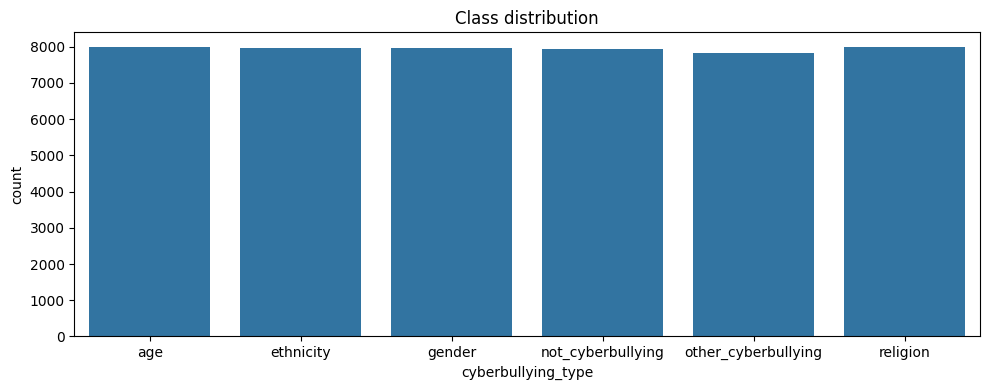

In [19]:
print(df.shape)
display(df['cyberbullying_type'].value_counts().sort_index())

plt.figure(figsize=(10, 4))
sns.countplot(
    data=df,
    x='cyberbullying_type',
    order=sorted(df['cyberbullying_type'].unique())
)
plt.title('Class distribution')
plt.tight_layout()
plt.savefig('images/class_distribution.png', dpi=200, bbox_inches='tight')
plt.show()


## 4. Data preparation


In [20]:
def clean_tweet(text: str) -> str:
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'@\w+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_tweet'] = df['tweet_text'].astype(str).map(clean_tweet)
df[['tweet_text', 'clean_tweet', 'cyberbullying_type']].head()


,tweet_text,clean_tweet,cyberbullying_type
0,"In other words #katandandre, your food was cra...","in other words #katandandre, your food was cra...",not_cyberbullying
1,Why is #aussietv so white? #MKR #theblock #ImA...,why is #aussietv so white? #mkr #theblock #ima...,not_cyberbullying
2,@XochitlSuckkks a classy whore? Or more red ve...,a classy whore? or more red velvet cupcakes?,not_cyberbullying
3,"@Jason_Gio meh. :P thanks for the heads up, b...","meh. :p thanks for the heads up, but not too c...",not_cyberbullying
4,@RudhoeEnglish This is an ISIS account pretend...,this is an isis account pretending to be a kur...,not_cyberbullying


## 5. Train/test split


In [22]:
RANDOM_STATE = 42
TEST_SIZE = 0.2

X = df['clean_tweet']
y = df['cyberbullying_type']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)


## 6. TF-IDF baseline


In [27]:

from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000,ngram_range=(1,3))),
    ('clf', LogisticRegression(max_iter=1000, verbose=1, class_weight=None))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.8232519131984485
F1 Score: 0.8241339825730227
Classification Report:
                      precision    recall  f1-score   support

                age       0.97      0.98      0.98      1598
          ethnicity       0.98      0.97      0.98      1592
             gender       0.90      0.82      0.86      1595
  not_cyberbullying       0.59      0.51      0.55      1589
other_cyberbullying       0.58      0.71      0.64      1565
           religion       0.95      0.94      0.95      1600

           accuracy                           0.82      9539
          macro avg       0.83      0.82      0.82      9539
       weighted avg       0.83      0.82      0.82      9539

Confusion Matrix:
 [[1568    2    2   19    6    1]
 [   1 1543    8    8   27    5]
 [   1    5 1313  129  139    8]
 [  32   10   69  814  613   51]
 [  13   11   59  359 1107   16]
 [   2    1    6   56   27 1508]]


In [23]:
def evaluate_predictions(y_true, y_pred):
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    macro = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    weighted = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'macro_precision': macro[0],
        'macro_recall': macro[1],
        'macro_f1': macro[2],
        'weighted_precision': weighted[0],
        'weighted_recall': weighted[1],
        'weighted_f1': weighted[2],
        'per_class_f1': {label: metrics['f1-score'] for label, metrics in report.items() if isinstance(metrics, dict)},
    }

tfidf_vectorizer = TfidfVectorizer(ngram_range=(1, 3), min_df=2)
tfidf_model = LogisticRegression(max_iter=1000)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)
tfidf_model.fit(X_train_tfidf, y_train)
tfidf_predictions = tfidf_model.predict(X_test_tfidf)
tfidf_results = evaluate_predictions(y_test, tfidf_predictions)
pd.Series({k: v for k, v in tfidf_results.items() if k != 'per_class_f1'})


accuracy              0.814551
macro_precision       0.814552
macro_recall          0.813745
macro_f1              0.812915
weighted_precision    0.815547
weighted_recall       0.814551
weighted_f1           0.813821
dtype: float64

## 7. Sentence Transformer experiment


In [28]:
# Replace the placeholder below with the exact sentence-transformer model used in the experiment.
SENTENCE_MODEL_NAME = 'all-MiniLM-L6-v2'
sentence_model = SentenceTransformer(SENTENCE_MODEL_NAME)

X_train_embeddings = sentence_model.encode(X_train.tolist(), show_progress_bar=True)
X_test_embeddings = sentence_model.encode(X_test.tolist(), show_progress_bar=True)

embedding_model = LogisticRegression(max_iter=1000)
embedding_model.fit(X_train_embeddings, y_train)
embedding_predictions = embedding_model.predict(X_test_embeddings)
embedding_results = evaluate_predictions(y_test, embedding_predictions)
pd.Series({k: v for k, v in embedding_results.items() if k != 'per_class_f1'})


Batches: 100%|██████████| 299/299 [00:43<00:00,  6.89it/s]


accuracy              0.813817
macro_precision       0.811647
macro_recall          0.813135
macro_f1              0.811713
weighted_precision    0.812436
weighted_recall       0.813817
weighted_f1           0.812452
dtype: float64

In [29]:
print("Accuracy:", accuracy_score(y_test, embedding_predictions))
print("F1 Score:", f1_score(y_test, embedding_predictions, average='weighted'))
print("Classification Report:\n", classification_report(y_test, embedding_predictions))
print("Confusion Matrix:\n", confusion_matrix(y_test, embedding_predictions))


Accuracy: 0.8138169619456966
F1 Score: 0.8124521612999853
Classification Report:
                      precision    recall  f1-score   support

                age       0.93      0.95      0.94      1598
          ethnicity       0.94      0.93      0.93      1592
             gender       0.83      0.83      0.83      1595
  not_cyberbullying       0.62      0.54      0.58      1589
other_cyberbullying       0.62      0.68      0.64      1565
           religion       0.93      0.95      0.94      1600

           accuracy                           0.81      9539
          macro avg       0.81      0.81      0.81      9539
       weighted avg       0.81      0.81      0.81      9539

Confusion Matrix:
 [[1523   11   11   29   21    3]
 [   8 1474   24   28   40   18]
 [  10   16 1329  115  112   13]
 [  56   21  102  863  470   77]
 [  34   22  117  324 1057   11]
 [   4   17   11   38   13 1517]]


## 8. Model comparison


                    representation  accuracy  macro_f1
0                           TF-IDF  0.814551  0.812915
1  Sentence Transformer embeddings  0.813817  0.811713


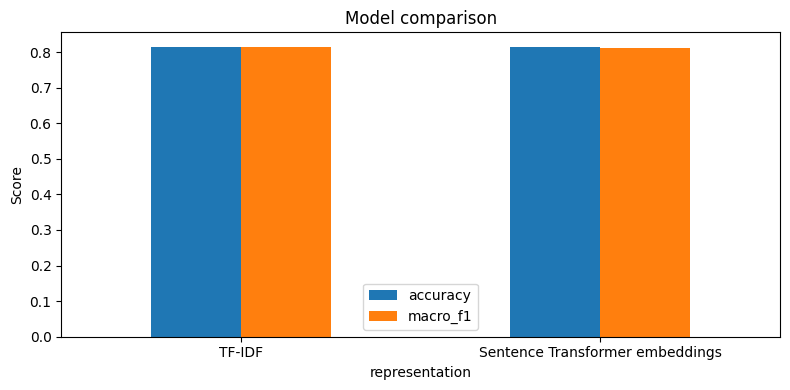

In [33]:
comparison_df = pd.DataFrame([
    {'representation': 'TF-IDF', 'accuracy': tfidf_results['accuracy'], 'macro_f1': tfidf_results['macro_f1']},
    {'representation': 'Sentence Transformer embeddings', 'accuracy': embedding_results['accuracy'], 'macro_f1': embedding_results['macro_f1']},
])
print(comparison_df)

ax = comparison_df.set_index('representation')[['accuracy', 'macro_f1']].plot(kind='bar', figsize=(8, 4))
ax.set_ylabel('Score')
ax.set_title('Model comparison')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('images/model_comparison.png', dpi=200, bbox_inches='tight')
plt.show()


## 9. Five-class experiment


In [40]:
five_class_df = df[df['cyberbullying_type'] != 'other_cyberbullying'].copy()

X_five = five_class_df['clean_tweet']
y_five = five_class_df['cyberbullying_type']

X_train_5, X_test_5, y_train_5, y_test_5 = train_test_split(
    X_five,
    y_five,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_five,
)

tfidf_vectorizer_5 = TfidfVectorizer(ngram_range=(1, 2), min_df=2)
tfidf_model_5 = LogisticRegression(max_iter=1000)

X_train_tfidf_5 = tfidf_vectorizer_5.fit_transform(X_train_5)
X_test_tfidf_5 = tfidf_vectorizer_5.transform(X_test_5)
tfidf_model_5.fit(X_train_tfidf_5, y_train_5)
tfidf_predictions_5 = tfidf_model_5.predict(X_test_tfidf_5)
five_class_results = evaluate_predictions(y_test_5, tfidf_predictions_5)
pd.Series({k: v for k, v in five_class_results.items() if k != 'per_class_f1'})
print("Accuracy:", accuracy_score(y_test_5, tfidf_predictions_5))
print("F1 Score:", f1_score(y_test_5, tfidf_predictions_5, average='weighted'))
print("Classification Report:\n", classification_report(y_test_5, tfidf_predictions_5))
print("Confusion Matrix:\n", confusion_matrix(y_test_5, tfidf_predictions_5))


Accuracy: 0.9295209430649611
F1 Score: 0.9298270362972129
Classification Report:
                    precision    recall  f1-score   support

              age       0.97      0.98      0.98      1598
        ethnicity       0.98      0.97      0.98      1592
           gender       0.94      0.86      0.90      1595
not_cyberbullying       0.82      0.88      0.85      1589
         religion       0.95      0.96      0.96      1600

         accuracy                           0.93      7974
        macro avg       0.93      0.93      0.93      7974
     weighted avg       0.93      0.93      0.93      7974

Confusion Matrix:
 [[1567    2    1   26    2]
 [   2 1546   11   25    8]
 [   4    7 1366  208   10]
 [  43   19   73 1395   59]
 [   0    2    4   56 1538]]


In [ ]:
 #Using sentence transformers and Logistic Regression after removing 'other_cyberbullying' class

print("Starting pipeline using Sentence Transformers and Logistic Regression after removing 'other_cyberbullying' class")
model = SentenceTransformer('all-MiniLM-L6-v2')
# Using sentence transformers and Logistic Regression after removing
# 'other_cyberbullying' class

print("Starting pipeline using Sentence Transformers and Logistic Regression after removing 'other_cyberbullying' class")

X_train_embeddings_5 = model.encode(
    X_train_5.tolist(),
    show_progress_bar=True
)
X_test_embeddings_5 = model.encode(
    X_test_5.tolist(),
    show_progress_bar=True
)

clf = LogisticRegression(max_iter=1000, verbose=1)
clf.fit(X_train_embeddings_5, y_train_5)

y_pred = clf.predict(X_test_embeddings_5)

print("Accuracy:", accuracy_score(y_test_5, y_pred))
print("F1 Score:", f1_score(y_test_5, y_pred, average='weighted'))
print("Classification Report:\n", classification_report(y_test_5, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test_5, y_pred))

Starting pipeline using Sentence Transformers and Logistic Regression after removing 'other_cyberbullying' class


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7624.39it/s]


Starting pipeline using Sentence Transformers and Logistic Regression after removing 'other_cyberbullying' class


Batches: 100%|██████████| 250/250 [00:40<00:00,  6.19it/s]


Accuracy: 0.9034361675445197
F1 Score: 0.9032784739473472
Classification Report:
                    precision    recall  f1-score   support

              age       0.95      0.96      0.95      1598
        ethnicity       0.95      0.94      0.94      1592
           gender       0.88      0.85      0.87      1595
not_cyberbullying       0.80      0.81      0.80      1589
         religion       0.93      0.96      0.95      1600

         accuracy                           0.90      7974
        macro avg       0.90      0.90      0.90      7974
     weighted avg       0.90      0.90      0.90      7974

Confusion Matrix:
 [[1529   10   10   47    2]
 [   6 1495   23   48   20]
 [  11   21 1360  191   12]
 [  64   33  132 1284   76]
 [   2   16   12   34 1536]]


## 10. Confusion matrix


FileNotFoundError: [Errno 2] No such file or directory: 'images/confusion_matrix.png'

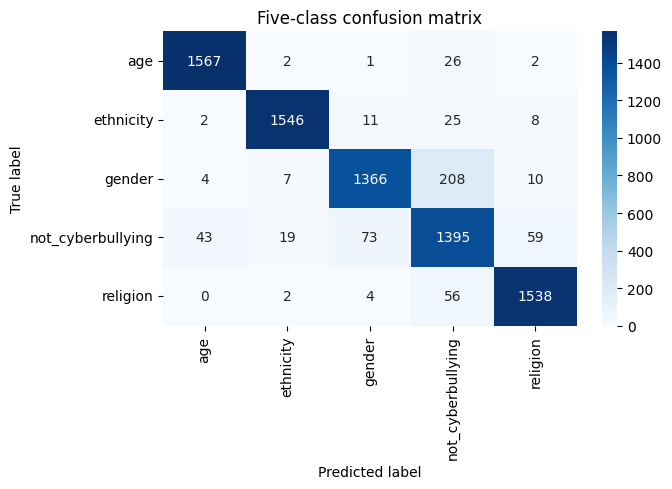

In [ ]:
five_class_labels = sorted(y_train_5.unique())
cm = confusion_matrix(y_test_5, tfidf_predictions_5, labels=five_class_labels)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=five_class_labels, yticklabels=five_class_labels)
plt.title('Five-class confusion matrix')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.tight_layout()
plt.savefig('images/confusion_matrix.png', dpi=200, bbox_inches='tight')
plt.show()


## 11. Error analysis


In [37]:
error_analysis_df = pd.DataFrame({
    'tweet': X_test_5.values,
    'true_label': y_test_5.values,
    'predicted_label': tfidf_predictions_5,
})

gender_to_non = error_analysis_df[(error_analysis_df['true_label'] == 'gender') & (error_analysis_df['predicted_label'] == 'not_cyberbullying')]
non_to_gender = error_analysis_df[(error_analysis_df['true_label'] == 'not_cyberbullying') & (error_analysis_df['predicted_label'] == 'gender')]

print('gender -> not_cyberbullying:', len(gender_to_non))
print('not_cyberbullying -> gender:', len(non_to_gender))

display(gender_to_non.head(10))
display(non_to_gender.head(10))


gender -> not_cyberbullying: 208
not_cyberbullying -> gender: 73


,tweet,true_label,predicted_label
35,rt : the truth behind another elimination roun...,gender,not_cyberbullying
43,someone really needs to get the sniffer dogs o...,gender,not_cyberbullying
92,#mkr #killerblondes two 7's? be fked they must...,gender,not_cyberbullying
201,hoe what its hitting for,gender,not_cyberbullying
253,it says women must stay at home and not displa...,gender,not_cyberbullying
370,prison is the same...except with more prison t...,gender,not_cyberbullying
376,your a cunt,gender,not_cyberbullying
462,"rt : loool what goes around comes around, kat ...",gender,not_cyberbullying
483,stupid. got it.,gender,not_cyberbullying
564,"if you talk the talk, you gotta walk the walk!...",gender,not_cyberbullying


,tweet,true_label,predicted_label
130,changing the definition of rape makes it easy ...,not_cyberbullying,gender
159,it's nikki's hot pot but she has katie make th...,not_cyberbullying,gender
424,#mkr wa r the biggest bitches ever,not_cyberbullying,gender
481,the fact that you don't think this tripe is se...,not_cyberbullying,gender
904,like it? minnesota gay teens bullied by adults...,not_cyberbullying,gender
914,rt :rt : katie and nikki need to be deported f...,not_cyberbullying,gender
1096,omg!!! bitches at my job are nasty,not_cyberbullying,gender
1171,michelle ( heartless bitch) bachman won't sign...,not_cyberbullying,gender
1217,just be careful who you align yourself with. s...,not_cyberbullying,gender
1356,mercy is a joke with all these shadows...,not_cyberbullying,gender


## 12. Conclusions

Reported project results:

- **Six-class TF-IDF + Logistic Regression** — Accuracy: `0.8177088863`, Macro F1: `0.8187764435`
- **Six-class Sentence Transformer + Logistic Regression** — Accuracy: `0.8105956046`, Macro F1: `0.8084662255`
- **Five-class TF-IDF + Logistic Regression** — Accuracy: `0.9277032160`, Macro F1: `0.9282693468`

The five-class result should be interpreted as a separate experiment with a different target space, not as a direct like-for-like improvement over the six-class setup.
